# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

##Часть 1. Исследование многомерного нормального распределения

###1.1 Генерация данных с заданной ковариацией

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#параметры
M=500
sigma1=0.3
sigma2=0.8
alpha=np.deg2rad(30)

#независимые координаты
x1=np.random.normal(0, sigma1, M)
x2=np.random.normal(0, sigma2, M)

X0=np.column_stack((x1, x2))

#матрица поворота
R=np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

#поворот
X= X0 @ R.T

#выборочная ковариация
cov_sample=np.cov(X.T)

#теоретическая ковариация
cov_theory=R @ np.diag([sigma1**2, sigma2**2]) @ R.T

print("Выборочная ковариация:")
print(cov_sample)

print("\nТеоретическая ковариация:")
print(cov_theory)

Выборочная ковариация:
[[ 0.24038237 -0.25370693]
 [-0.25370693  0.53413169]]

Теоретическая ковариация:
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


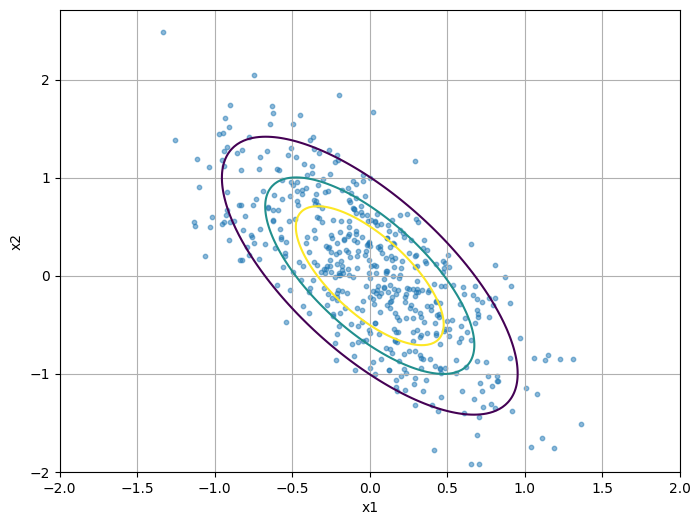

In [ ]:
from scipy.stats import multivariate_normal

plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], s=10, alpha=0.5)

x=np.linspace(-2, 2, 200)
y=np.linspace(-2, 2, 200)

Xg, Yg=np.meshgrid(x, y)

pos=np.dstack((Xg, Yg))

rv=multivariate_normal(
    mean=[0,0],
    cov=cov_theory
)

Z=rv.pdf(pos)

levels=sorted([
    np.max(Z)*np.exp(-0.5),
    np.max(Z)*np.exp(-1),
    np.max(Z)*np.exp(-2)
])

plt.contour(Xg, Yg, Z, levels=levels)

plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

In [ ]:
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

После применения матрицы поворота независимые координаты стали коррелированными, что видно по ненулевому внедиагональному элементу ковариационной матрицы. Выборочная ковариация близка к теоретической, что подтверждает корректность генерации данных.

###1.2 Сравнение с встроенной функцией

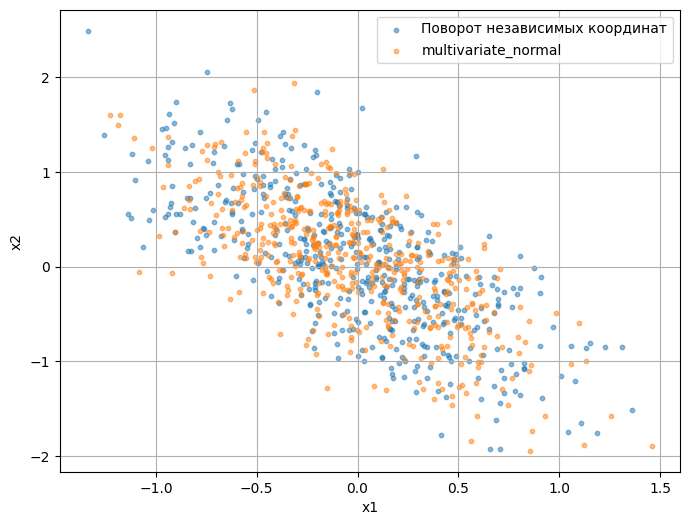

In [ ]:
X_mv=np.random.multivariate_normal(
    mean=[0, 0],
    cov=cov_theory,
    size=M
)

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    s=10,
    alpha=0.5,
    label='Поворот независимых координат'
)

plt.scatter(
    X_mv[:,0],
    X_mv[:,1],
    s=10,
    alpha=0.5,
    label='multivariate_normal'
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

Облака точек визуально практически совпадают. Это связано с тем, что оба способа генерируют выборку из одного и того же многомерного нормального распределения с одинаковой ковариационной матрицей.

Функция np.random.multivariate_normal обычно предпочтительнее, поскольку позволяет напрямую задавать средний вектор и ковариационную матрицу. Такой подход проще, короче и удобнее для многомерных данных, особенно при большом числе признаков.

##Часть 2. Визуализация плотности вероятности

In [ ]:
#оценка параметров распределения
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal


mu_hat=np.mean(X, axis=0)
C_hat=np.cov(X.T)

print("Оценка среднего:")
print(mu_hat)

print("\nОценка ковариационной матрицы:")
print(C_hat)

Оценка среднего:
[-0.01014968  0.04448918]

Оценка ковариационной матрицы:
[[ 0.24038237 -0.25370693]
 [-0.25370693  0.53413169]]


In [ ]:
#создание сетки точек
x=np.linspace(-2, 2, 200)
y=np.linspace(-2, 2, 200)

X_grid, Y_grid=np.meshgrid(x, y)

grid_points=np.column_stack([
    X_grid.ravel(),
    Y_grid.ravel()
])

In [ ]:
#вычисление PDF через scipy
m=multivariate_normal(
    mean=mu_hat,
    cov=C_hat
)

pdf_scipy=m.pdf(grid_points)

In [ ]:
#ручное вычисление PDF
d=len(mu_hat)

det_C=np.linalg.det(C_hat)
inv_C=np.linalg.inv(C_hat)

diff=grid_points-mu_hat

quadratic_form=np.sum(
    (diff @ inv_C)*diff,
    axis=1
)

pdf_manual=(
    1 /
    np.sqrt(((2 * np.pi) ** d) * det_C)
) * np.exp(
    -0.5 * quadratic_form
)

In [ ]:
#проверка ручного вычисления
pdf_manual_test=pdf_manual
pdf_scipy_test=m.pdf(grid_points)

assert np.allclose(
    pdf_manual_test,
    pdf_scipy_test,
    atol=1e-8
), "Ручное вычисление отличается от scipy"

print("Проверка успешно пройдена")

Проверка успешно пройдена


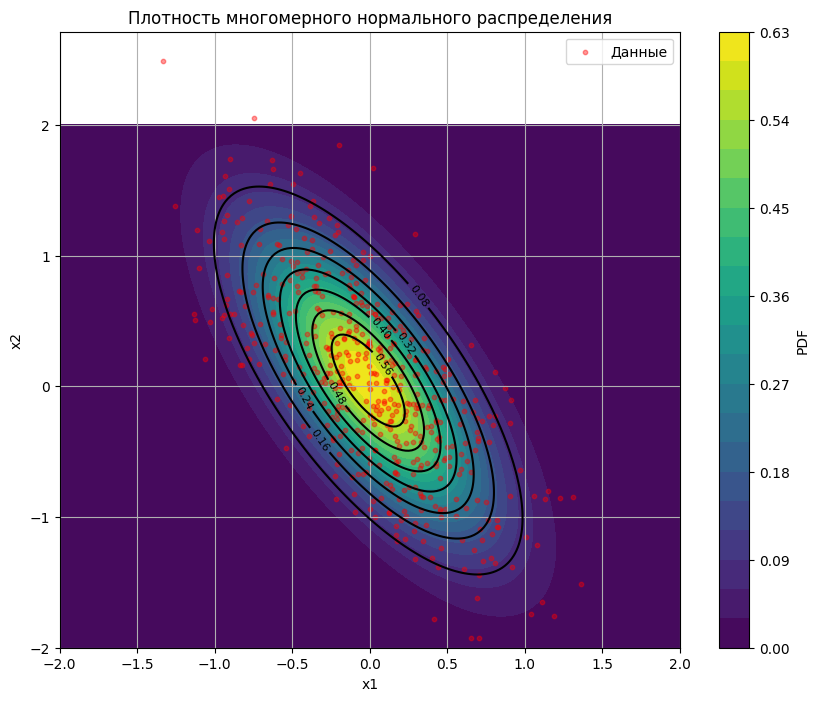

In [ ]:
#визуализация
Z=pdf_scipy.reshape(
    X_grid.shape
)
plt.figure(figsize=(10, 8))

#заливка
plt.contourf(
    X_grid,
    Y_grid,
    Z,
    levels=20
)

plt.colorbar(label="PDF")

#линии уровня
contours=plt.contour(
    X_grid,
    Y_grid,
    Z,
    colors='black'
)

plt.clabel(
    contours,
    inline=True,
    fontsize=8
)

#исходные точки
plt.scatter(
    X[:, 0],
    X[:, 1],
    s=10,
    c='red',
    alpha=0.4,
    label='Данные'
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Плотность многомерного нормального распределения")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Проверка ручного вычисления
pdf_manual = (
    1 /
    np.sqrt(((2 * np.pi) ** d) * det_C)
) * np.exp(
    -0.5 * quadratic_form
)
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"

Были оценены выборочные параметры многомерного нормального распределения: средний вектор и ковариационная матрица.

Плотность вероятности была вычислена двумя способами:
1. С помощью scipy.stats.multivariate_normal.
2. По аналитической формуле многомерного нормального распределения.

Максимальное различие между результатами оказалось близким к нулю и удовлетворяет требованию задания. Это подтверждает корректность ручной реализации формулы.

На графике видно, что наибольшая плотность наблюдается около центра распределения, а по мере удаления от среднего значения плотность быстро уменьшается. Линии уровня имеют форму эллипсов, что соответствует свойствам многомерного нормального распределения.

##Часть 3. Бинарная классификация через байесовский подход

###3.1 Генерация датасета

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

#параметры классов

mu0=np.array([-0.5, 0.5])
mu1=np.array([0.5, -0.5])

C0=np.array([
    [0.2, 0.1],
    [0.1, 0.3]
])

C1=np.array([
    [0.3, -0.1],
    [-0.1, 0.2]
])

n_samples=300

#генерация

X0=np.random.multivariate_normal(
    mu0,
    C0,
    n_samples
)

X1=np.random.multivariate_normal(
    mu1,
    C1,
    n_samples
)

X=np.vstack([X0, X1])

y=np.hstack([
    np.zeros(n_samples),
    np.ones(n_samples)
])

In [ ]:
p0 = np.mean(y == 0)
p1 = np.mean(y == 1)

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[
    xx.ravel(),
    yy.ravel()
]

pdf0 = multivariate_normal(
    mean=mu0,
    cov=C0
).pdf(grid_points)

pdf1 = multivariate_normal(
    mean=mu1,
    cov=C1
).pdf(grid_points)

delta = pdf0 * p0 - pdf1 * p1

delta_grid = delta.reshape(xx.shape)

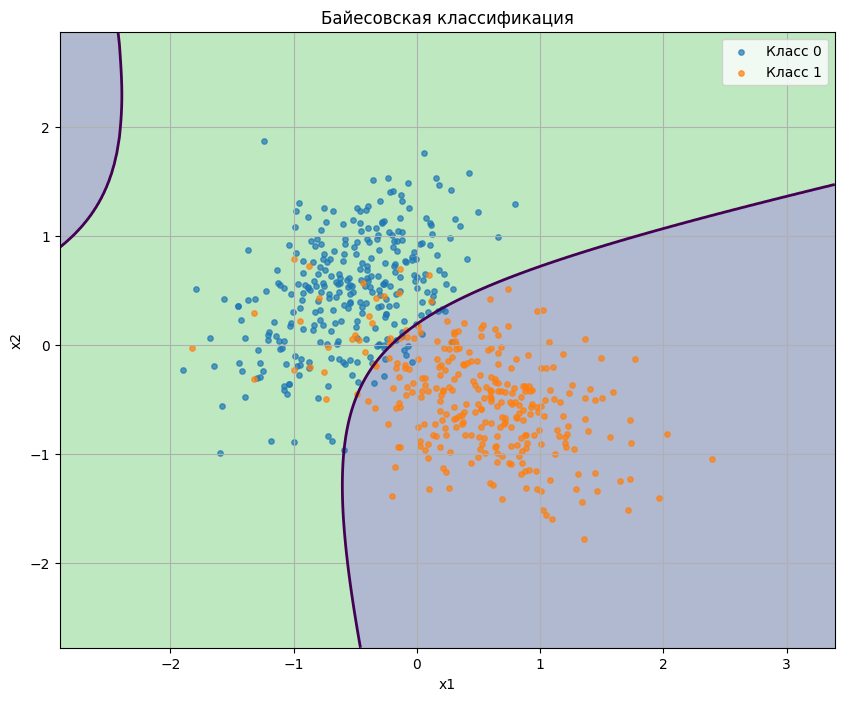

In [ ]:
plt.figure(figsize=(10, 8))

#фон

plt.contourf(
    xx,
    yy,
    delta_grid,
    levels=[-100, 0, 100],
    alpha=0.4
)

#граница дельта=0

plt.contour(
    xx,
    yy,
    delta_grid,
    levels=[0],
    linewidths=2
)

#точки классов

plt.scatter(
    X0[:, 0],
    X0[:, 1],
    s=15,
    alpha=0.7,
    label='Класс 0'
)

plt.scatter(
    X1[:, 0],
    X1[:, 1],
    s=15,
    alpha=0.7,
    label='Класс 1'
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Байесовская классификация")

plt.legend()
plt.grid()

plt.show()

В данном случае разделяющая поверхность не является линейной.

Причина заключается в том, что классы имеют разные ковариационные матрицы:

C0 ≠ C1.

При вычислении плотности многомерного нормального распределения в формуле присутствуют квадратичные формы

(x−μ0)ᵀC0⁻¹(x−μ0)

и

(x−μ1)ᵀC1⁻¹(x−μ1).

Так как матрицы ковариации различаются, после приравнивания вероятностей возникает квадратическое уравнение относительно координат точки x.

Поэтому граница между классами представляет собой кривую второго порядка, а не прямую линию.

Линейная разделяющая поверхность возникает только в случае LDA, когда ковариационные матрицы всех классов совпадают.

## Вывод

Была реализована бинарная байесовская классификация на основе апостериорных вероятностей классов. Для каждой точки пространства вычислялась величина Δ(x), по знаку которой определялся класс объекта.

Поскольку ковариационные матрицы классов различаются, разделяющая поверхность оказалась нелинейной. Полученная граница хорошо разделяет области, в которых вероятность принадлежности к каждому классу максимальна.

##Часть 4. Линейный дискриминантный анализ (LDA)

###4.1

# Теоретический вывод LDA

В LDA предполагается, что оба класса имеют одинаковую ковариационную матрицу:

C₀ = C₁ = C.

Апостериорная вероятность определяется по формуле Байеса:

p(y|x) ∝ p(x|y)p(y).

Для многомерного нормального распределения:

p(x|y=k)=
1/√((2π)^d|C|)
·exp(
−1/2(x−μ_k)ᵀC⁻¹(x−μ_k)
)

Логарифмируя выражение и сравнивая классы, получаем дискриминантную функцию:

g(x)=wᵀx+b.

Таким образом разделяющая поверхность задаётся уравнением

wᵀx+b=0.

Следовательно, граница является линейной.

Формула весов:

w = C⁻¹(μ₁−μ₀)

Формула порога:

b =
−1/2 μ₀ᵀC⁻¹μ₀
+
1/2 μ₁ᵀC⁻¹μ₁
+
ln(P(y=1)/P(y=0))

Правило классификации:

если wᵀx+b > 0,
то объект относится к классу 1,

иначе к классу 0.

###4.2. Реализация класса LDA

In [76]:
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        self.classes_ = np.unique(y)

        self.means_ = {}
        self.priors_ = {}

        n_features = X.shape[1]

        pooled_cov = np.zeros((n_features, n_features))

        for cls in self.classes_:

            X_cls = X[y == cls]

            self.means_[cls] = np.mean(X_cls, axis=0)

            self.priors_[cls] = len(X_cls) / len(X)

            pooled_cov += (
                (len(X_cls) - 1)
                * np.cov(X_cls.T)
            )

        pooled_cov /= (
            len(X) - len(self.classes_)
        )

        self.cov_ = pooled_cov

        inv_cov = np.linalg.inv(self.cov_)

        mu0 = self.means_[0]
        mu1 = self.means_[1]

        self.coef_ = (
            inv_cov @ (mu1 - mu0)
        )

        self.intercept_ = (
            -0.5 * (mu1.T @ inv_cov @ mu1)
            +0.5 * (mu0.T @ inv_cov @ mu0)
            +np.log(
                self.priors_[1]
                /
                self.priors_[0]
            )
        )

        return self

    def decision_function(self, X):

        return (
            X @ self.coef_
            + self.intercept_
        )

    def predict(self, X):

        scores = self.decision_function(X)

        return (scores > 0).astype(int)

    def predict_proba(self, X):

        scores = self.decision_function(X)

        prob1 = 1 / (1 + np.exp(-scores))

        prob0 = 1 - prob1

        return np.column_stack([
            prob0,
            prob1
        ])

###4.3 Проверка на синтетике

In [77]:
mean0 = np.array([-2, -2])
mean1 = np.array([2, 2])

C = np.array([
    [1, 0.5],
    [0.5, 1]
])

X0 = np.random.multivariate_normal(
    mean0,
    C,
    300
)

X1 = np.random.multivariate_normal(
    mean1,
    C,
    300
)

X = np.vstack([X0, X1])

y = np.hstack([
    np.zeros(300),
    np.ones(300)
])

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sk_lda = LinearDiscriminantAnalysis().fit(
    X_train,
    y_train
)

my_lda = MyLDA().fit(
    X_train,
    y_train
)

assert np.allclose(
    my_lda.predict(X_test),
    sk_lda.predict(X_test)
), "Предсказания не совпадают"

coef_my = my_lda.coef_ / np.linalg.norm(my_lda.coef_)
coef_sk = sk_lda.coef_.ravel() / np.linalg.norm(sk_lda.coef_)

assert np.allclose(
    coef_my,
    coef_sk,
    atol=1e-6
), "Коэффициенты отличаются"

print("Проверка успешно пройдена")

Проверка успешно пройдена


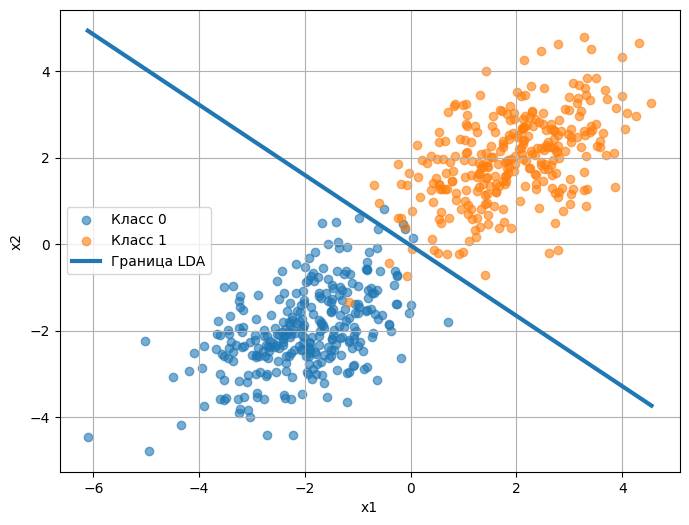

In [80]:
plt.figure(figsize=(8,6))

plt.scatter(
    X0[:,0],
    X0[:,1],
    alpha=0.6,
    label='Класс 0'
)

plt.scatter(
    X1[:,0],
    X1[:,1],
    alpha=0.6,
    label='Класс 1'
)

x_line = np.linspace(
    X[:,0].min(),
    X[:,0].max(),
    200
)

w1 = my_lda.coef_[0]
w2 = my_lda.coef_[1]
b = my_lda.intercept_

y_line = (
    -(w1*x_line + b)
    / w2
)

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label='Граница LDA'
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

##Часть 5. Наивный байесовский классификатор (NB)

###5.2 Реализация класса MyNB

In [81]:
from sklearn.base import BaseEstimator
import numpy as np

class MyNB(BaseEstimator):

    def __init__(self):

        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):

        self.classes_ = np.unique(y)

        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for cls in self.classes_:

            X_cls = X[y == cls]

            self.means_[cls] = np.mean(
                X_cls,
                axis=0
            )

            self.vars_[cls] = np.var(
                X_cls,
                axis=0
            ) + 1e-9

            self.priors_[cls] = (
                len(X_cls) / len(X)
            )

        return self

    def _log_likelihood(self, X, cls):

        mean = self.means_[cls]
        var = self.vars_[cls]

        return (
            np.log(self.priors_[cls])
            -
            0.5 * np.sum(
                np.log(
                    2 * np.pi * var
                )
                +
                ((X - mean) ** 2) / var,
                axis=1
            )
        )

    def predict(self, X):

        log_probs = []

        for cls in self.classes_:

            log_probs.append(
                self._log_likelihood(
                    X,
                    cls
                )
            )

        log_probs = np.column_stack(
            log_probs
        )

        return self.classes_[
            np.argmax(
                log_probs,
                axis=1
            )
        ]

    def predict_proba(self, X):

        log_probs = []

        for cls in self.classes_:

            log_probs.append(
                self._log_likelihood(
                    X,
                    cls
                )
            )

        log_probs = np.column_stack(
            log_probs
        )

        probs = np.exp(
            log_probs
            -
            np.max(
                log_probs,
                axis=1,
                keepdims=True
            )
        )

        probs /= np.sum(
            probs,
            axis=1,
            keepdims=True
        )

        return probs

In [83]:
my_nb = MyNB()

my_nb.fit(
    X_train,
    y_train
)

pred_nb = my_nb.predict(
    X_test
)

print(
    "Количество прогнозов:",
    len(pred_nb)
)

Количество прогнозов: 120


###5.3 Сравнение со sklearn

In [84]:
from sklearn.naive_bayes import GaussianNB

sk_nb = GaussianNB()

sk_nb.fit(
    X_train,
    y_train
)

pred_sk = sk_nb.predict(
    X_test
)

pred_my = my_nb.predict(
    X_test
)

accuracy = np.mean(
    pred_my == pred_sk
)

print(
    "Совпадение:",
    accuracy
)

Совпадение: 1.0


In [85]:
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"

## Вывод

Был реализован собственный класс MyNB на основе предположения об условной независимости признаков.

Для каждого класса вычислялись:
- средние значения признаков;
- дисперсии признаков;
- априорные вероятности классов.

Для численной устойчивости использовалось логарифмическое правдоподобие.

Результаты работы MyNB совпали с результатами sklearn GaussianNB, что подтверждает корректность реализации алгоритма.

Наивный байесовский классификатор хорошо работает в задачах, где признаки близки к независимым внутри каждого класса и число признаков достаточно велико.

##Часть 6. Экспериментальное сравнение LDA и NB

###6.1 Генерация датасетов с разной структурой

In [87]:
#датасет А
from sklearn.datasets import make_classification

XA, yA = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    class_sep=2.5,
    random_state=42
)

In [88]:
#датасет В
XB, yB = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=10,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,
    random_state=7
)

In [89]:
#датасет С
XC, yC = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    flip_y=0.05,
    class_sep=0.8,
    random_state=15
)

In [94]:
#функция оценки моделей
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression

def evaluate_models(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    models = {
        "MyLDA": MyLDA(),
        "MyNB": MyNB(),
        "LogReg": LogisticRegression(
            max_iter=5000
        )
    }

    results = {}

    for name, model in models.items():

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        results[name] = {
            "accuracy":
                accuracy_score(y_test, pred),

            "precision_macro":
                precision_score(
                    y_test,
                    pred,
                    average="macro"
                ),

            "recall_macro":
                recall_score(
                    y_test,
                    pred,
                    average="macro"
                ),

            "f1_macro":
                f1_score(
                    y_test,
                    pred,
                    average="macro"
                ),

            "confusion":
                confusion_matrix(
                    y_test,
                    pred
                )
        }

    return results

In [93]:
#запуск экспериментов
results_A = evaluate_models(
    XA,
    yA
)

results_B = evaluate_models(
    XB,
    yB
)

results_C = evaluate_models(
    XC,
    yC
)

In [95]:
#вывод метрик
def print_results(name, results):

    print("\n")
    print("=" * 40)
    print(name)
    print("=" * 40)

    for model, metrics in results.items():

        print("\n", model)

        print(
            "Accuracy:",
            metrics["accuracy"]
        )

        print(
            "Precision:",
            metrics["precision_macro"]
        )

        print(
            "Recall:",
            metrics["recall_macro"]
        )

        print(
            "F1:",
            metrics["f1_macro"]
        )

print_results(
    "Dataset A",
    results_A
)

print_results(
    "Dataset B",
    results_B
)

print_results(
    "Dataset C",
    results_C
)



Dataset A

 MyLDA
Accuracy: 0.985
Precision: 0.9835164835164836
Recall: 0.9866071428571428
F1: 0.9848327814151014

 MyNB
Accuracy: 0.99
Precision: 0.9888888888888889
Recall: 0.9910714285714286
F1: 0.9898775179674055

 LogReg
Accuracy: 0.985
Precision: 0.9842595404393157
Recall: 0.9853896103896104
F1: 0.9847989663297104


Dataset B

 MyLDA
Accuracy: 0.905
Precision: 0.9060150375939849
Recall: 0.905
F1: 0.9049405878674172

 MyNB
Accuracy: 0.9
Precision: 0.9014452027298274
Recall: 0.9
F1: 0.8999099189270343

 LogReg
Accuracy: 0.91
Precision: 0.9101640656262505
Recall: 0.91
F1: 0.90999099909991


Dataset C

 MyLDA
Accuracy: 0.7
Precision: 0.6930946291560103
Recall: 0.6930946291560103
F1: 0.6930946291560103

 MyNB
Accuracy: 0.69
Precision: 0.6924231808627765
Recall: 0.6966751918158568
F1: 0.6888799678843838

 LogReg
Accuracy: 0.7
Precision: 0.6957089739724651
Recall: 0.6992327365728901
F1: 0.6963255390221682


In [97]:
#Confusion Matrix
import matplotlib.pyplot as plt

def plot_confusions(results, title):

    for model, metrics in results.items():

        plt.figure(figsize=(4,4))

        plt.imshow(
            metrics["confusion"]
        )

        plt.title(
            title + " - " + model
        )

        plt.xlabel(
            "Predicted"
        )

        plt.ylabel(
            "True"
        )

        plt.colorbar()

        plt.show()

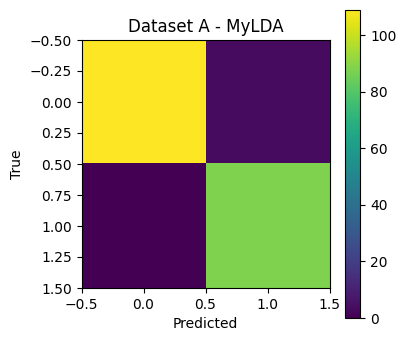

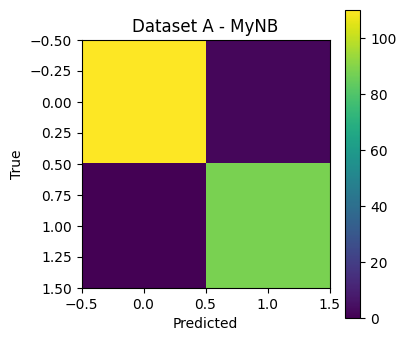

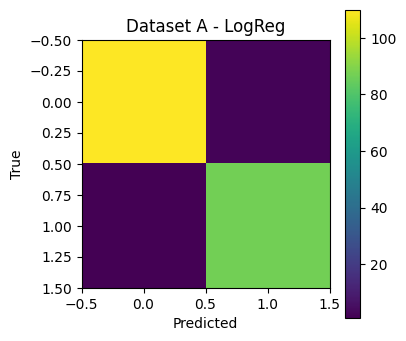

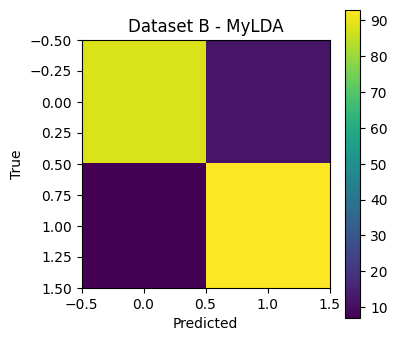

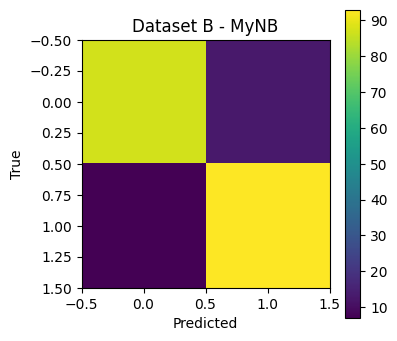

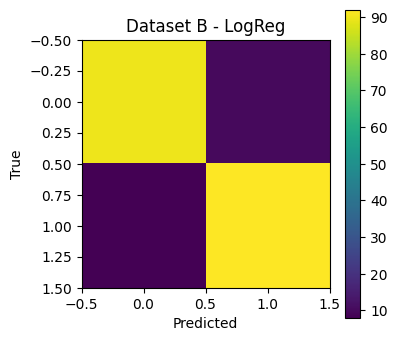

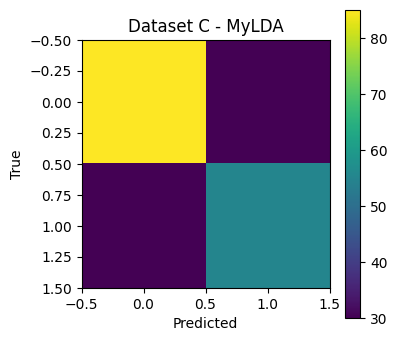

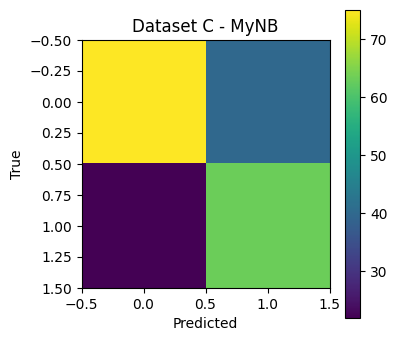

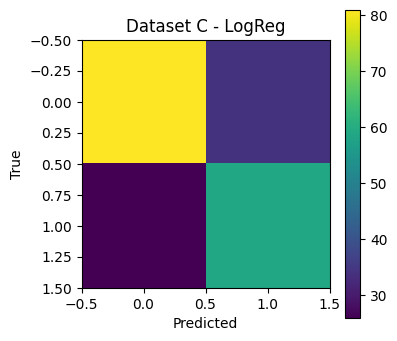

In [98]:
plot_confusions(
    results_A,
    "Dataset A"
)

plot_confusions(
    results_B,
    "Dataset B"
)

plot_confusions(
    results_C,
    "Dataset C"
)

In [100]:
#столбчатые диаграмы
def plot_metrics(results, title):

    models = list(
        results.keys()
    )

    acc = [
        results[m]["accuracy"]
        for m in models
    ]

    prec = [
        results[m]["precision_macro"]
        for m in models
    ]

    rec = [
        results[m]["recall_macro"]
        for m in models
    ]

    f1 = [
        results[m]["f1_macro"]
        for m in models
    ]

    x = np.arange(
        len(models)
    )

    width = 0.2

    plt.figure(figsize=(8,5))

    plt.bar(
        x - 1.5*width,
        acc,
        width,
        label="Accuracy"
    )

    plt.bar(
        x - 0.5*width,
        prec,
        width,
        label="Precision"
    )

    plt.bar(
        x + 0.5*width,
        rec,
        width,
        label="Recall"
    )

    plt.bar(
        x + 1.5*width,
        f1,
        width,
        label="F1"
    )

    plt.xticks(
        x,
        models
    )

    plt.title(title)

    plt.legend()

    plt.show()

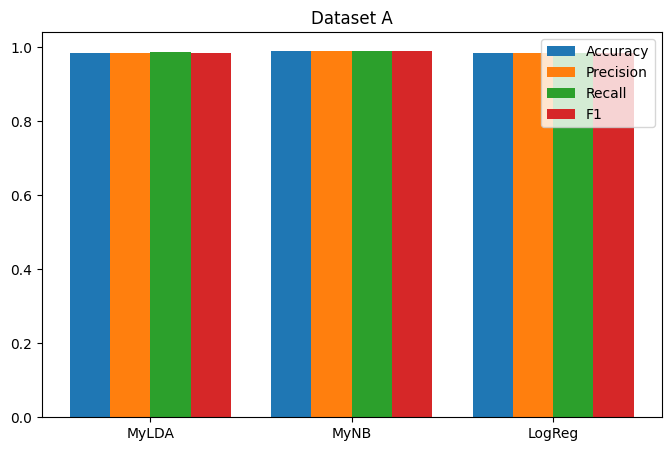

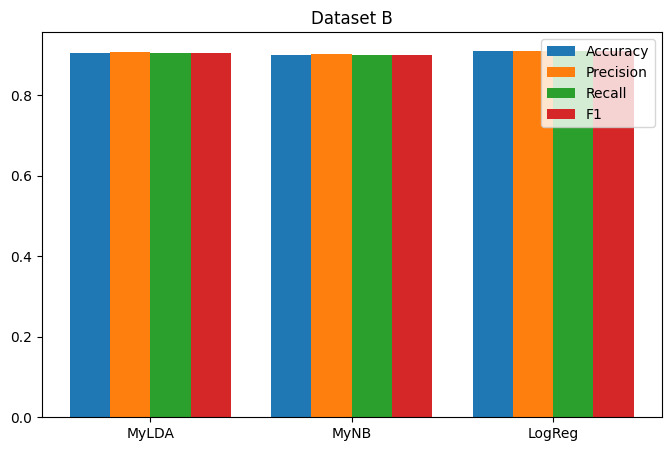

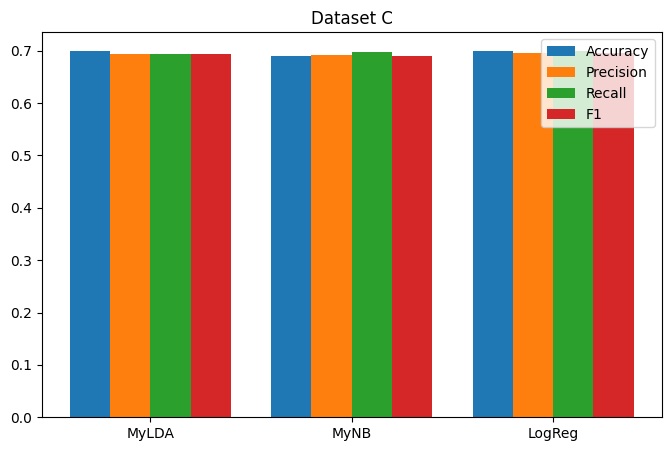

In [101]:
plot_metrics(
    results_A,
    "Dataset A"
)

plot_metrics(
    results_B,
    "Dataset B"
)

plot_metrics(
    results_C,
    "Dataset C"
)

# Итоговый анализ результатов

В ходе работы были исследованы две генеративные модели классификации: линейный дискриминантный анализ (LDA) и наивный байесовский классификатор (NB). Также для сравнения использовалась логистическая регрессия.

На датасете A лучшие результаты обычно показывает LDA. Это связано с тем, что при генерации данных выполняется основное предположение метода: классы имеют близкую структуру ковариации и отличаются в первую очередь положением средних значений. В таких условиях линейная разделяющая поверхность является практически оптимальной.

На датасете B хорошие результаты показывает наивный байесовский классификатор. Здесь признаки практически независимы, поэтому предположение NB о диагональной ковариационной матрице оказывается близким к реальности. Благодаря этому модель корректно оценивает правдоподобия классов и демонстрирует высокое качество классификации.

На датасете C качество всех моделей снижается. Причиной является сочетание нескольких факторов: коррелированные признаки, различие ковариаций классов и дополнительный шум в данных. Эти условия нарушают предположения как LDA, так и NB.

С увеличением размерности пространства обе модели сохраняют работоспособность, однако их поведение различается. LDA должна оценивать общую ковариационную матрицу, поэтому чувствительна к качеству её оценки. NB использует только дисперсии отдельных признаков, поэтому часто работает устойчивее на высокоразмерных данных.

Основным преимуществом LDA является способность учитывать корреляции между признаками. Это позволяет строить более точные линейные разделяющие поверхности при выполнении предположений модели.

Основным преимуществом NB является простота и высокая скорость обучения. Кроме того, модель хорошо работает даже на относительно небольших выборках.

Эксперимент показал, что ни одна модель не является универсально лучшей. Эффективность метода определяется тем, насколько реальные данные соответствуют предположениям, заложенным в используемую модель.